In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ruta_carpeta = Path(
    "../Resultados/02_Tablas_de_metricas_por_lead"
)

ruta_salida = Path(
    "../Resultados/03_Graficos_por_lead_perc_50"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo seleccionar la métrica que se quiere graficar

In [6]:
# Métrica a evaluar
# puede ser: NS,Pbias,CV,Pearson,CRPSSad,Brier_Q10,Brier_Q10_Q25,Brier_Q25_Q75,Brier_Q75_Q90,Brier_Q90
metrica_evaluar = "NS"

In [7]:
# Acumulador intercuenca
inter_cuenca = []

for ruta_csv in ruta_carpeta.glob("*.csv"):
    df = pd.read_csv(ruta_csv)

    cuenca = ruta_csv.stem  # nombre del archivo = cuenca

    # chequeo defensivo
    if metrica_evaluar not in df.columns:
        raise ValueError(f"{metrica_evaluar} no está en {ruta_csv.name}")

    # extraer lead + métrica
    tmp = df[["lead", metrica_evaluar]].copy()
    tmp["cuenca"] = cuenca

    inter_cuenca.append(tmp)


           p25       p50
lead                    
1     0.117538  0.177567
2    -0.037698  0.040369
3    -0.081984 -0.023023
4    -0.099791 -0.035680
5    -0.108826 -0.040959
6    -0.112219 -0.038457


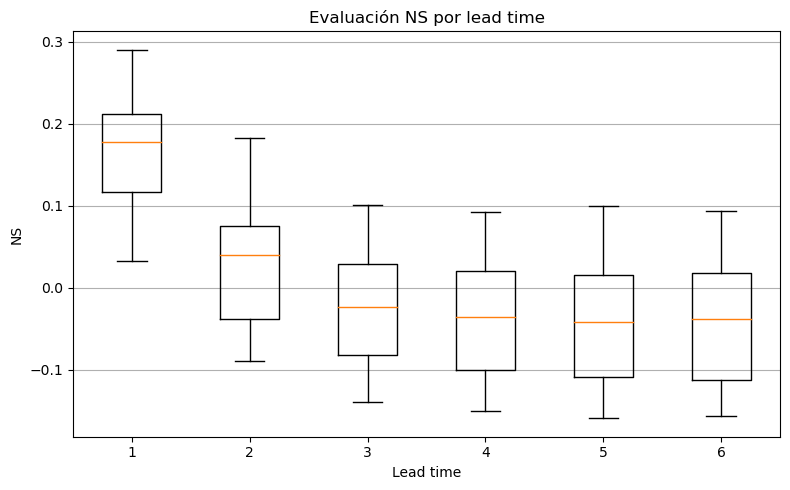

In [8]:
# DataFrame final y graficar

inter_cuenca = pd.concat(inter_cuenca, ignore_index=True)


percentiles = (
    inter_cuenca
    .groupby("lead")[metrica_evaluar]
    .quantile([0.25, 0.50])
    .unstack()
    .rename(columns={0.25: "p25", 0.50: "p50"})
)

print(percentiles)

leads = sorted(inter_cuenca["lead"].unique())

box_data = [
    inter_cuenca.loc[inter_cuenca["lead"] == l, metrica_evaluar].dropna()
    for l in leads
]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, labels=leads, showfliers=True)
plt.xlabel("Lead time")
plt.ylabel(metrica_evaluar)
plt.title(f"Evaluación {metrica_evaluar} por lead time")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(ruta_salida / f"Brier_boxplot_{metrica_evaluar}.png", dpi=300)
plt.show()

